# Stage 4 v4 — HybridVQC (Quantum + Classical Head)
## Explainable Hybrid Quantum-Classical NIDS
**Version 4.0 | March 2026**

### What changed from v3 (Adam) — and why it hits F1 ≥ 0.60

| Fix | v3 | v4 | Expected gain |
|---|---|---|---|
| **Classical head** | None (VQC → 5 logits direct) | 8→64→5 Tanh MLP on top of VQC | +0.10–0.15 F1 |
| **VQC outputs** | 5 Pauli-Z (only NUM_CLASSES qubits) | ALL 8 Pauli-Z (full qubit state) | +0.03–0.05 F1 |
| **Training data** | 10K (hybrid stratified) | 60K (20K Normal, 10K each attack) | +0.05–0.10 F1 |
| **Loss** | Weighted CE | Focal loss (γ=2) + class weights + L2 | +0.03–0.08 F1 |
| **LR schedule** | Constant 0.005 | Cosine annealing (0.005→1e-5, warmup=30) | +0.02–0.04 F1 |
| **Restarts** | 1 run | 3 restarts → best val F1 selected | +0.01–0.03 F1 |
| **Temperature scaling** | None | Post-hoc T calibration on val set | +0.01–0.02 F1 |
| **Mini-batch** | Full 10K per epoch | batch=5000, 12 updates/epoch | Faster convergence |

**Architecture:** `8D VAE latent → VQC (8 qubits, 24 params) → 8 Pauli-Z values → Dense(64) → Tanh → Dense(5)`

The classical head is the key fix. Without it, the decision boundary in the 8D expectation-value space is **linear**. The MLP head makes it **nonlinear**, which is essential for 5-class separation.

**Target: F1-macro ≥ 0.60**

In [1]:
import zipfile
import os

zip_files = ["vae_a_output_16.zip", "vae_b_output_16.zip"]

for z in zip_files:
    folder_name = z.replace(".zip", "")  # creates separate folder per zip
    os.makedirs(folder_name, exist_ok=True)
    
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall(folder_name)

print("Extraction completed separately.")

Extraction completed separately.


In [2]:
# ============================================================
# Cell 1 — Package Installation
# ============================================================
import subprocess, sys

def pip(*args):
    cmd = [sys.executable, '-m', 'pip', 'install', '--quiet',
           '--break-system-packages'] + list(args)
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  [WARN] {" ".join(args[:2])}: {r.stderr[-200:]}')
    return r.returncode

print('Step 1/4 - JAX CUDA 12 (0.4.28)...')
rc = pip('jax[cuda12_pip]==0.4.28',
         '-f', 'https://storage.googleapis.com/jax-releases/jax_cuda_releases.html')
if rc != 0:
    pip('jax==0.4.28', 'jaxlib==0.4.28+cuda12.cudnn89',
        '-f', 'https://storage.googleapis.com/jax-releases/jax_cuda_releases.html')
print('  ok  jax==0.4.28')

print('Step 2/4 - PennyLane 0.38.0 (force reinstall)...')
for pkg in ['pennylane==0.38.0', 'pennylane-lightning==0.38.0',
            'pennylane-lightning-gpu==0.38.0']:
    rc = pip('--force-reinstall', pkg)
    print(f'  {"ok" if rc==0 else "WARN"}  {pkg}')

print('Step 3/4 - autoray 0.6.7...')
pip('autoray==0.6.7')
print('  ok')

print('Step 4/4 - Supporting packages...')
for pkg in ['kagglehub', 'scikit-learn>=1.4', 'scipy>=1.12',
            'numpy>=1.26,<2.0', 'pandas>=2.2', 'pyarrow>=14.0',
            'matplotlib>=3.7', 'seaborn>=0.13']:
    rc = pip(pkg)
    print(f'  {"ok" if rc==0 else "WARN"}  {pkg}')

print('\nAll packages installed.')

Step 1/4 - JAX CUDA 12 (0.4.28)...
  ok  jax==0.4.28
Step 2/4 - PennyLane 0.38.0 (force reinstall)...
  ok  pennylane==0.38.0
  ok  pennylane-lightning==0.38.0
  ok  pennylane-lightning-gpu==0.38.0
Step 3/4 - autoray 0.6.7...
  ok
Step 4/4 - Supporting packages...
  ok  kagglehub
  ok  scikit-learn>=1.4
  ok  scipy>=1.12
  ok  numpy>=1.26,<2.0
  ok  pandas>=2.2
  ok  pyarrow>=14.0
  ok  matplotlib>=3.7
  ok  seaborn>=0.13

All packages installed.


In [3]:
# ============================================================
# Cell 2 — Imports, GPU Detection, and PennyLane Device
# ============================================================
import os, time, json, warnings, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelBinarizer

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

import jax
import jax.numpy as jnp
from jax import jit, vmap, value_and_grad
import pennylane as qml

print('=' * 60)
print('  ENVIRONMENT VERIFICATION')
print('=' * 60)
jax_backend = jax.default_backend()
print(f'  JAX version   : {jax.__version__}')
print(f'  JAX backend   : {jax_backend}')
print(f'  JAX devices   : {jax.devices()}')
print(f'  PennyLane     : {qml.__version__}')

if qml.__version__ != '0.38.0':
    print(f'  [WARN] PennyLane is {qml.__version__}, expected 0.38.0')
    print('         Run Cell 1 again with kernel restart')
else:
    print('  PennyLane 0.38.0 : CONFIRMED ok')

if jax_backend != 'gpu':
    print('  [WARN] JAX on CPU — training will be slower')
else:
    print('  JAX GPU           : CONFIRMED')

# Device selection: try fastest first
PENNYLANE_DEVICE = None
DEVICE_NAME      = None
for dev_name, dev_label in [
    ('lightning.gpu',     'Lightning-GPU (CUDA, fastest)'),
    ('default.qubit.jax', 'default.qubit.jax (JAX backprop)'),
    ('default.qubit',     'default.qubit (CPU fallback)'),
]:
    try:
        _d = qml.device(dev_name, wires=2)
        qml.QNode(lambda: qml.expval(qml.PauliZ(0)), _d)()
        PENNYLANE_DEVICE = dev_name
        DEVICE_NAME      = dev_label
        print(f'  {dev_name:<22s}: AVAILABLE <- using this')
        break
    except Exception as e:
        print(f'  {dev_name:<22s}: unavailable ({type(e).__name__})')

if PENNYLANE_DEVICE is None:
    raise RuntimeError('No PennyLane device available!')

# backprop enables exact JAX gradients through the quantum circuit
DIFF_METHOD = 'backprop' if 'jax' in PENNYLANE_DEVICE else 'best'
print(f'  diff_method   : {DIFF_METHOD}')
print('=' * 60)

  ENVIRONMENT VERIFICATION
  JAX version   : 0.4.28
  JAX backend   : gpu
  JAX devices   : [cuda(id=0)]
  PennyLane     : 0.38.0
  PennyLane 0.38.0 : CONFIRMED ok
  JAX GPU           : CONFIRMED
  lightning.gpu         : unavailable (ImportError)


2026-03-20 11:00:54.064967: W external/xla/xla/service/gpu/nvptx_compiler.cc:760] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


  default.qubit.jax     : AVAILABLE <- using this
  diff_method   : backprop


In [4]:
# ============================================================
# Cell 3 — Configuration (v4)
# ============================================================
NOTEBOOK_DIR = os.getcwd()

# Input: VAE latent vectors from Stage 3
VAE_A_DIR = os.path.join(NOTEBOOK_DIR, 'vae_a_output_16')  # 167-feature VAE
VAE_B_DIR = os.path.join(NOTEBOOK_DIR, 'vae_b_output_16')  # 140-feature VAE

# Output directories (v4 — separate from v3 to preserve v3 results)
VQC_A_DIR = os.path.join(NOTEBOOK_DIR, 'vqc_a_output_v4')
VQC_B_DIR = os.path.join(NOTEBOOK_DIR, 'vqc_b_output_v4')
os.makedirs(VQC_A_DIR, exist_ok=True)
os.makedirs(VQC_B_DIR, exist_ok=True)

# ── Quantum circuit ────────────────────────────────────────
NUM_QUBITS  = 8
NUM_CLASSES = 5
RA_REPS     = 2
ZZ_REPS     = 2
N_PARAMS    = NUM_QUBITS * (RA_REPS + 1)   # 24

# ── Classical head ─────────────────────────────────────────
HIDDEN_DIM     = 128    # was 64 — more capacity needed
N_CLASSICAL    = NUM_QUBITS * HIDDEN_DIM + HIDDEN_DIM + HIDDEN_DIM * NUM_CLASSES + NUM_CLASSES
N_TOTAL_PARAMS = N_PARAMS + N_CLASSICAL

# ── Phase 1: train classical head ONLY (quantum params frozen) ──
# Avoids barren plateau: quantum params at fixed near-zero values
# produce stable (non-vanishing) Pauli-Z outputs for the head to learn from
PHASE1_EPOCHS   = 150
PHASE1_LR       = 0.01    # aggressive LR — classical head trains fast
PHASE1_PATIENCE = 30

# ── Phase 2: joint fine-tuning (quantum + classical together) ──
PHASE2_EPOCHS   = 100
PHASE2_LR       = 0.001   # 10x lower — quantum params are fragile
PHASE2_PATIENCE = 40

# ── Shared ─────────────────────────────────────────────────
ADAM_LR        = PHASE1_LR   
ADAM_LR_MIN    = 1e-5
ADAM_WARMUP    = 10
ADAM_B1        = 0.9
ADAM_B2        = 0.999
ADAM_EPS       = 1e-8
BATCH_SIZE     = 2000
LOG_EVERY      = 10
N_RESTARTS     = 2
RESTART_SEEDS  = [42, 123]
FOCAL_GAMMA    = 2.0
L2_WEIGHT      = 1e-4

# ── Training subset ────────────────────────────────────────
HYBRID_COUNTS  = {0: 8000, 1: 3000, 2: 3000, 3: 3000, 4: 3000}
N_TRAIN        = sum(HYBRID_COUNTS.values())   # 20,000
VAL_FRAC       = 0.10
EVAL_BATCH     = 10000
CLASS_NAMES    = ['NORMALL', 'DoSD', 'PROBE', 'EXPLOIT', 'MALWARE']
N_EPOCHS = 100  # or whatever number of epochs you want
PATIENCE = 20   # early stopping patience
_counts        = np.array([HYBRID_COUNTS[i] for i in range(NUM_CLASSES)], dtype=np.float32)
CLASS_WEIGHTS  = _counts.max() / _counts

print(f'Phase 1 (classical only): {PHASE1_EPOCHS} epochs  lr={PHASE1_LR}')
print(f'Phase 2 (joint finetune): {PHASE2_EPOCHS} epochs  lr={PHASE2_LR}')
print(f'Head: {NUM_QUBITS}→{HIDDEN_DIM}→{NUM_CLASSES}  |  Train: {N_TRAIN:,} samples')

print('=' * 70)
print('  STAGE 4 v4 — HybridVQC (Quantum + Classical Head)')
print('=' * 70)
print(f'  Qubits          : {NUM_QUBITS}')
print(f'  ZZFeatureMap    : reps={ZZ_REPS}')
print(f'  RealAmplitudes  : reps={RA_REPS} → {N_PARAMS} quantum params')
print(f'  VQC output      : ALL {NUM_QUBITS} Pauli-Z values  (v3 used only {NUM_CLASSES})')
print(f'  Classical head  : {NUM_QUBITS} → {HIDDEN_DIM} → {NUM_CLASSES}  (Tanh + Dense)')
print(f'  Classical params: {N_CLASSICAL}')
print(f'  Total params    : {N_TOTAL_PARAMS}  (was 24 in v3)')
print(f'  Loss            : Focal (γ={FOCAL_GAMMA}) + class weights + L2={L2_WEIGHT}')
print(f'  Class weights   : {CLASS_WEIGHTS.tolist()}')
print(f'  Optimizer       : Adam + cosine LR [{ADAM_LR}→{ADAM_LR_MIN}] warmup={ADAM_WARMUP}')
print(f'  Train samples   : {N_TRAIN:,}  (v3 had 10,000)')
print(f'  Batch size      : {BATCH_SIZE}  ({N_TRAIN // BATCH_SIZE} batches/epoch)')
print(f'  Epochs/restart  : {N_EPOCHS}  patience={PATIENCE}')
print(f'  Restarts        : {N_RESTARTS}  seeds={RESTART_SEEDS}')
print(f'  PennyLane dev   : {DEVICE_NAME}')
print('=' * 70)

Phase 1 (classical only): 150 epochs  lr=0.01
Phase 2 (joint finetune): 100 epochs  lr=0.001
Head: 8→128→5  |  Train: 20,000 samples
  STAGE 4 v4 — HybridVQC (Quantum + Classical Head)
  Qubits          : 8
  ZZFeatureMap    : reps=2
  RealAmplitudes  : reps=2 → 24 quantum params
  VQC output      : ALL 8 Pauli-Z values  (v3 used only 5)
  Classical head  : 8 → 128 → 5  (Tanh + Dense)
  Classical params: 1797
  Total params    : 1821  (was 24 in v3)
  Loss            : Focal (γ=2.0) + class weights + L2=0.0001
  Class weights   : [1.0, 2.6666667461395264, 2.6666667461395264, 2.6666667461395264, 2.6666667461395264]
  Optimizer       : Adam + cosine LR [0.01→1e-05] warmup=10
  Train samples   : 20,000  (v3 had 10,000)
  Batch size      : 2000  (10 batches/epoch)
  Epochs/restart  : 100  patience=20
  Restarts        : 2  seeds=[42, 123]
  PennyLane dev   : default.qubit.jax (JAX backprop)


In [6]:
# ============================================================
# Cell 4 — Data Loading (labels + VAE latent vectors)
# ============================================================
import kagglehub

# ── Kaggle credentials ────────────────────────────────────
_src = None
for _loc in [NOTEBOOK_DIR, '/workspace', '/root', os.path.expanduser('~')]:
    _c = os.path.join(_loc, 'kaggle.json')
    if os.path.exists(_c):
        _src = _c; break
if _src is None:
    raise FileNotFoundError('kaggle.json not found — place it in the notebook directory')
_kdir = os.path.expanduser('~/.kaggle')
os.makedirs(_kdir, exist_ok=True)
_dst  = os.path.join(_kdir, 'kaggle.json')
shutil.copy2(_src, _dst)
os.chmod(_dst, 0o600)
print(f'kaggle.json configured: {_dst}')

def find_file(base, name):
    for root, _, files in os.walk(base):
        if name in files:
            return os.path.join(root, name)
    return None

# ── Labels: must come from stage-2-output-v2 (matches z_train row count) ──
print('\nDownloading stage-2-output-v2 (labels only)...')
s2v2_path    = kagglehub.dataset_download('monadarling143/stage-2-output-v2')
y_train_path = find_file(s2v2_path, 'stage2_y_train.parquet')
y_test_path  = find_file(s2v2_path, 'stage2_y_test.parquet')

if y_train_path is None:
    raise FileNotFoundError('stage2_y_train.parquet not found in v2 dataset')

y_train_df = pd.read_parquet(y_train_path)
y_test_df  = pd.read_parquet(y_test_path)
lcol       = y_train_df.columns[0]
Y_TRAIN    = y_train_df[lcol].values.astype(int)
Y_TEST     = y_test_df[lcol].values.astype(int)
print(f'  Y_TRAIN : {Y_TRAIN.shape}  classes={np.unique(Y_TRAIN)}')
print(f'  Y_TEST  : {Y_TEST.shape}   classes={np.unique(Y_TEST)}')

# ── VAE latent vectors (local) ────────────────────────────
print('\nLoading VAE latent vectors (local files)...')
Z_TRAIN_A = pd.read_parquet(os.path.join(VAE_A_DIR, 'vae_a_z_train.parquet')).values.astype(np.float32)
Z_TEST_A  = pd.read_parquet(os.path.join(VAE_A_DIR, 'vae_a_z_test.parquet')).values.astype(np.float32)
Z_TRAIN_B = pd.read_parquet(os.path.join(VAE_B_DIR, 'vae_b_z_train.parquet')).values.astype(np.float32)
Z_TEST_B  = pd.read_parquet(os.path.join(VAE_B_DIR, 'vae_b_z_test.parquet')).values.astype(np.float32)

print(f'  Z_TRAIN_A: {Z_TRAIN_A.shape}  Z_TRAIN_B: {Z_TRAIN_B.shape}')
print(f'  Z_TEST_A : {Z_TEST_A.shape}   Z_TEST_B : {Z_TEST_B.shape}')

# ── Verify angle constraints (VAE must output values in [0, pi]) ──
print('\nAngle verification:')
for tag, Z in [('Z_TRAIN_A', Z_TRAIN_A), ('Z_TEST_A', Z_TEST_A),
               ('Z_TRAIN_B', Z_TRAIN_B), ('Z_TEST_B', Z_TEST_B)]:
    assert Z.shape[1] == NUM_QUBITS, f'{tag}: expected {NUM_QUBITS} dims got {Z.shape[1]}'
    assert not np.isnan(Z).any(), f'{tag}: NaN detected'
    assert not np.isinf(Z).any(), f'{tag}: Inf detected'
    assert Z.min() >= 0 and Z.max() <= np.pi + 1e-5, f'{tag}: out of [0, pi]'
    std  = Z.std(axis=0)
    coll = int((std < 0.3).sum())
    print(f'  [{tag}] range=[{Z.min():.3f},{Z.max():.3f}]  collapsed_dims={coll}/8  std_min={std.min():.3f}')

# ── Row-count alignment check ────────────────────────────
assert Z_TRAIN_A.shape[0] == len(Y_TRAIN), \
    f'Z_TRAIN_A rows ({Z_TRAIN_A.shape[0]}) != Y_TRAIN ({len(Y_TRAIN)})'
assert Z_TRAIN_B.shape[0] == len(Y_TRAIN), \
    f'Z_TRAIN_B rows ({Z_TRAIN_B.shape[0]}) != Y_TRAIN ({len(Y_TRAIN)})'
print('\nRow-count alignment: OK')
print('Data loading complete.')

kaggle.json configured: /root/.kaggle/kaggle.json



100%|██████████| 1.66G/1.66G [00:49<00:00, 35.6MB/s]

Extracting files...


  Y_TRAIN : (2381042,)  classes=[0 1 2 3 4]
  Y_TEST  : (573807,)   classes=[0 1 2 3 4]

Loading VAE latent vectors (local files)...
  Z_TRAIN_A: (2381042, 8)  Z_TRAIN_B: (2381042, 8)
  Z_TEST_A : (573807, 8)   Z_TEST_B : (573807, 8)

Angle verification:
  [Z_TRAIN_A] range=[0.000,3.142]  collapsed_dims=0/8  std_min=0.658
  [Z_TEST_A] range=[0.000,3.142]  collapsed_dims=0/8  std_min=0.656
  [Z_TRAIN_B] range=[0.000,3.142]  collapsed_dims=0/8  std_min=0.612
  [Z_TEST_B] range=[0.000,3.142]  collapsed_dims=0/8  std_min=0.555

Row-count alignment: OK
Data loading complete.


In [7]:
# ============================================================
# Cell 5 — Circuit v4 + Classical Head + JIT Verification
# ============================================================
#
# v4 KEY CHANGE: vqc_circuit now returns ALL 8 Pauli-Z expectation values
# instead of only 5 (NUM_CLASSES). This gives the classical head 8 features
# to work with instead of 5, using ALL qubit information.
#
# Classical head: 8 → HIDDEN_DIM → 5
#   vqc_out ∈ [-1, 1]^8  (Pauli-Z expectation values)
#   h       = Tanh(vqc_out @ W1 + b1)  ∈ (-1, 1)^64
#   logits  = h @ W2 + b2               ∈ R^5
# WHY TANH NOT RELU: Tanh preserves the [-1,1] scale of quantum outputs.
# ReLU would kill negative expectation values (half the signal).

dev = qml.device(PENNYLANE_DEVICE, wires=NUM_QUBITS)
print(f'Device  : {PENNYLANE_DEVICE}  wires={NUM_QUBITS}')
print(f'Diff    : {DIFF_METHOD}')

@qml.qnode(dev, interface='jax', diff_method=DIFF_METHOD)
def vqc_circuit(x, weights):
    # Layer 1: Angle encoding — VAE latent angles map to qubit RY rotations
    for i in range(NUM_QUBITS):
        qml.RY(x[i], wires=i)

    # Layer 2: ZZFeatureMap (reps=2) — pairwise qubit entanglement from data
    # Creates feature interactions: x[i] * x[j] couples qubits i and j
    for _ in range(ZZ_REPS):
        for i in range(NUM_QUBITS):
            for j in range(i + 1, NUM_QUBITS):
                qml.IsingZZ(x[i] * x[j], wires=[i, j])

    # Layer 3: RealAmplitudes (reps=2) — trainable ansatz (24 params)
    # RA_REPS=2 keeps barren plateau risk lower than reps=3
    w_idx = 0
    for _ in range(RA_REPS):
        for i in range(NUM_QUBITS):
            qml.RY(weights[w_idx], wires=i); w_idx += 1
        for i in range(NUM_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
    for i in range(NUM_QUBITS):
        qml.RY(weights[w_idx], wires=i); w_idx += 1

    # v4: output ALL 8 qubits (v3 output only 5 for NUM_CLASSES)
    return tuple(qml.expval(qml.PauliZ(i)) for i in range(NUM_QUBITS))

# Vectorize over batch: maps (N, 8) input → (N, 8) expectation values
batched_circuit = jit(
    lambda x, w: jnp.stack(
        vmap(vqc_circuit, in_axes=(0, None))(x, w),
        axis=1
    )
)

def init_params(seed=SEED):
    """Initialize quantum + classical head parameters."""
    rng = np.random.RandomState(seed)
    # Quantum: near-zero init (flat loss landscape with clear gradient direction)
    # Avoids saturated RY rotations at ±pi/2 where gradients vanish
    q  = jnp.array(rng.normal(0.0, 0.1, N_PARAMS), dtype=jnp.float32)
    # Classical: Glorot uniform (preserves signal variance through layers)
    s1 = np.sqrt(6.0 / (NUM_QUBITS + HIDDEN_DIM))
    s2 = np.sqrt(6.0 / (HIDDEN_DIM + NUM_CLASSES))
    W1 = jnp.array(rng.uniform(-s1, s1, (NUM_QUBITS, HIDDEN_DIM)), dtype=jnp.float32)
    b1 = jnp.zeros(HIDDEN_DIM,  dtype=jnp.float32)
    W2 = jnp.array(rng.uniform(-s2, s2, (HIDDEN_DIM, NUM_CLASSES)), dtype=jnp.float32)
    b2 = jnp.zeros(NUM_CLASSES, dtype=jnp.float32)
    return {'q': q, 'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}

def forward(params, X):
    """
    End-to-end differentiable forward pass.
    X: (N, 8) latent angles in [0, pi]
    returns: (N, 5) class logits
    Both quantum and classical gradients flow through jax.value_and_grad.
    """
    vqc_out = batched_circuit(X, params['q'])            # (N, 8) ∈ [-1, 1]
    h       = jnp.tanh(vqc_out @ params['W1'] + params['b1'])  # (N, 64)
    logits  = h @ params['W2'] + params['b2']            # (N, 5)
    return logits

# ── JIT warmup ────────────────────────────────────────────
print('\nJIT compilation (first call includes trace time)...')
_p  = init_params(42)
_dx = jnp.ones((4, NUM_QUBITS), dtype=jnp.float32) * 1.5
t0  = time.time()
_out = forward(_p, _dx)
_out.block_until_ready()
print(f'JIT done in {time.time()-t0:.1f}s  output shape: {_out.shape}')
assert _out.shape == (4, NUM_CLASSES)

# ── Gradient test ─────────────────────────────────────────
print('\nGradient test (both quantum + classical params)...')
_l, _g = jax.value_and_grad(lambda p: forward(p, _dx).mean())(_p)
_gq = float(jnp.linalg.norm(_g['q']))
_gW = float(jnp.linalg.norm(_g['W1']))
print(f'  |grad_q|={_gq:.6f}  |grad_W1|={_gW:.6f}')
if _gq < 1e-10:
    print('  [CRITICAL] Zero quantum gradient — check PL version and diff_method')
else:
    print('  Gradient flow confirmed (quantum + classical). ok')

# ── Timing estimate ────────────────────────────────────────
print('\nTiming estimate (full batch=5000)...')
_dx5k = jnp.ones((BATCH_SIZE, NUM_QUBITS), dtype=jnp.float32) * 1.5
t0    = time.time()
_l5k, _g5k = jax.value_and_grad(lambda p: forward(p, _dx5k).mean())(_p)
_l5k.block_until_ready()
t_batch = time.time() - t0
n_batches_est = N_TRAIN // BATCH_SIZE
print(f'  Batch={BATCH_SIZE}: {t_batch:.2f}s  →  {n_batches_est} batches/epoch → '
      f'{t_batch*n_batches_est:.1f}s/epoch')
total_est = t_batch * n_batches_est * N_EPOCHS * N_RESTARTS / 60
print(f'  Estimated total ({N_RESTARTS} restarts × {N_EPOCHS} epochs): {total_est:.0f} min')
print(f'  (Early stopping will terminate many restarts before {N_EPOCHS} epochs)')

print(f'\n  Total trainable: {N_PARAMS} quantum + {N_CLASSICAL} classical = {N_TOTAL_PARAMS} params')

Device  : default.qubit.jax  wires=8
Diff    : backprop

JIT compilation (first call includes trace time)...
JIT done in 3.2s  output shape: (4, 5)

Gradient test (both quantum + classical params)...
  |grad_q|=0.119658  |grad_W1|=0.152749
  Gradient flow confirmed (quantum + classical). ok

Timing estimate (full batch=5000)...
  Batch=2000: 5.70s  →  10 batches/epoch → 57.0s/epoch
  Estimated total (2 restarts × 100 epochs): 190 min
  (Early stopping will terminate many restarts before 100 epochs)

  Total trainable: 24 quantum + 1797 classical = 1821 params


In [8]:
# ============================================================
# Cell 6 — Focal Loss, Cosine LR, Pytree Adam, Utilities
# ============================================================

# ── Loss functions ─────────────────────────────────────────

def focal_loss_full(params, X, y_oh, cw, gamma=FOCAL_GAMMA, l2=L2_WEIGHT):
    """Full forward pass: quantum + classical head. Used in Phase 2."""
    logits    = forward(params, X)
    proba     = jax.nn.softmax(logits, axis=1)
    proba_c   = jnp.clip(proba, 1e-7, 1.0)
    pt        = jnp.sum(y_oh * proba_c, axis=1)
    focal_wt  = (1.0 - pt) ** gamma
    sample_cw = jnp.sum(y_oh * cw[None, :], axis=1)
    ce        = -jnp.sum(y_oh * jnp.log(proba_c), axis=1)
    base_loss = jnp.mean(focal_wt * sample_cw * ce)
    l2_loss   = l2 * (jnp.sum(params['W1'] ** 2) + jnp.sum(params['W2'] ** 2))
    return base_loss + l2_loss

def focal_loss_classical_only(classical_params, q_fixed, X, y_oh, cw,
                               gamma=FOCAL_GAMMA, l2=L2_WEIGHT):
    """
    Phase 1: quantum params are FROZEN (passed separately, no gradient).
    Only W1, b1, W2, b2 receive gradients.
    
    Why this works: fixed near-zero quantum params produce stable Pauli-Z outputs
    in [-1, 1]^8. The classical head can learn a nonlinear classifier on these
    stable features WITHOUT fighting vanishing quantum gradients.
    Once the head converges (Phase 1), Phase 2 fine-tunes everything jointly
    with a much smaller LR so quantum params can move without destabilizing head.
    """
    # Forward pass using fixed quantum params — no gradient flows to q_fixed
    vqc_out = batched_circuit(X, q_fixed)                        # (N, 8), no grad
    h       = jnp.tanh(vqc_out @ classical_params['W1'] + classical_params['b1'])
    logits  = h @ classical_params['W2'] + classical_params['b2']

    proba     = jax.nn.softmax(logits, axis=1)
    proba_c   = jnp.clip(proba, 1e-7, 1.0)
    pt        = jnp.sum(y_oh * proba_c, axis=1)
    focal_wt  = (1.0 - pt) ** gamma
    sample_cw = jnp.sum(y_oh * cw[None, :], axis=1)
    ce        = -jnp.sum(y_oh * jnp.log(proba_c), axis=1)
    base_loss = jnp.mean(focal_wt * sample_cw * ce)
    l2_loss   = l2 * (jnp.sum(classical_params['W1'] ** 2) +
                      jnp.sum(classical_params['W2'] ** 2))
    return base_loss + l2_loss

# JIT-compiled gradient functions
loss_and_grad_phase1 = jit(value_and_grad(focal_loss_classical_only))
loss_and_grad_phase2 = jit(value_and_grad(focal_loss_full))


# ── Cosine LR schedule ─────────────────────────────────────
def cosine_lr(epoch, n_epochs, base_lr, min_lr=ADAM_LR_MIN, warmup=ADAM_WARMUP):
    """Linear warmup + cosine annealing. epoch is 0-indexed."""
    if epoch < warmup:
        return float(base_lr * (epoch + 1) / warmup)
    progress = (epoch - warmup) / max(1, n_epochs - warmup)
    return float(min_lr + 0.5 * (base_lr - min_lr) * (1 + np.cos(np.pi * progress)))


# ── Pytree Adam ───────────────────────────────────────────
# JAX treats dicts as pytrees natively: tree_map applies element-wise across
# all leaves (q, W1, b1, W2, b2) without explicit loops.

def adam_init(params):
    m = jax.tree_util.tree_map(jnp.zeros_like, params)
    v = jax.tree_util.tree_map(jnp.zeros_like, params)
    return m, v

def adam_update(params, m, v, t, grads, lr_val):
    """One Adam step on a JAX pytree. Works for dict of any shape arrays."""
    lr  = jnp.float32(lr_val)
    t_n = t + jnp.float32(1.0)
    m_n = jax.tree_util.tree_map(lambda mi, gi: ADAM_B1*mi + (1-ADAM_B1)*gi, m, grads)
    v_n = jax.tree_util.tree_map(lambda vi, gi: ADAM_B2*vi + (1-ADAM_B2)*gi**2, v, grads)
    mh  = jax.tree_util.tree_map(lambda mi: mi/(1 - ADAM_B1**t_n), m_n)
    vh  = jax.tree_util.tree_map(lambda vi: vi/(1 - ADAM_B2**t_n), v_n)
    p_n = jax.tree_util.tree_map(
        lambda pi, mhi, vhi: pi - lr * mhi / (jnp.sqrt(vhi) + ADAM_EPS),
        params, mh, vh)
    return p_n, m_n, v_n, t_n


# ── Prediction + metric utilities ────────────────────────

def predict_logits(params, Z, batch_size=EVAL_BATCH):
    """Batch inference for large datasets (573K test set)."""
    n = len(Z)
    out = []
    for s in range(0, n, batch_size):
        e  = min(s + batch_size, n)
        lg = forward(params, jnp.array(Z[s:e], dtype=jnp.float32))
        lg.block_until_ready()
        out.append(np.array(lg, dtype=np.float32))
    return np.concatenate(out, axis=0)  # (N, 5)


def val_f1_macro(params, X_val_np, Y_val_np):
    """Quick val F1-macro for early stopping."""
    lg    = predict_logits(params, X_val_np)
    preds = np.argmax(lg, axis=1)
    return f1_score(Y_val_np, preds, average='macro', zero_division=0)


def find_best_temperature(logits_val, y_val):
    """
    Post-hoc temperature scaling: find T that maximizes val F1-macro.
    Dividing logits by T > 1 softens probabilities (helps overconfident models).
    Dividing by T < 1 sharpens them (helps underconfident models).
    """
    temps = [0.3, 0.5, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0]
    best_T, best_f1 = 1.0, -1.0
    for T in temps:
        preds = np.argmax(logits_val / T, axis=1)
        f1    = f1_score(y_val, preds, average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_T = f1, T
    return float(best_T), float(best_f1)


def build_train_val(Z, Y, train_counts=None, val_frac=VAL_FRAC, seed=SEED):
    """
    Build stratified train/val split.
    val_frac of each class is held out for early stopping + temperature scaling.
    """
    if train_counts is None:
        train_counts = HYBRID_COUNTS
    rng = np.random.RandomState(seed)
    tr_idx, va_idx = [], []
    for cls, n in train_counts.items():
        cls_idx = np.where(Y == cls)[0]
        if len(cls_idx) == 0:
            print(f'  [WARN] class {cls} has 0 samples'); continue
        chosen = rng.choice(cls_idx, size=min(n, len(cls_idx)), replace=False)
        n_val  = max(2, int(len(chosen) * val_frac))
        va_idx.extend(chosen[:n_val].tolist())
        tr_idx.extend(chosen[n_val:].tolist())
    tr_idx = np.array(tr_idx)
    va_idx = np.array(va_idx)
    rng.shuffle(tr_idx)
    return Z[tr_idx], Y[tr_idx], Z[va_idx], Y[va_idx], tr_idx, va_idx


def print_full_metrics(tag, logits, Y, T=1.0):
    """Full classification report with per-class F1."""
    preds  = np.argmax(logits / T, axis=1)
    f1_mac = f1_score(Y, preds, average='macro',    zero_division=0)
    f1_wt  = f1_score(Y, preds, average='weighted', zero_division=0)
    acc    = accuracy_score(Y, preds)
    print(f'\n  {tag}  T={T:.2f}')
    print(f'  {"-"*55}')
    print(f'  F1-macro  : {f1_mac:.4f}  {"✓ TARGET MET (≥0.60)" if f1_mac >= 0.60 else f"GAP = {0.60-f1_mac:.4f}"}')
    print(f'  F1-wt     : {f1_wt:.4f}')
    print(f'  Accuracy  : {acc:.4f}')
    f1_cls = {}
    for i, name in enumerate(CLASS_NAMES):
        pm = preds == i;   tm = Y == i
        tp = int((pm & tm).sum()); fp = int((pm & ~tm).sum())
        fn = int((~pm & tm).sum())
        pr = tp / (tp + fp + 1e-10)
        rc = tp / (tp + fn + 1e-10)
        f1 = 2 * pr * rc / (pr + rc + 1e-10)
        f1_cls[name] = float(f1)
        print(f'  {name:<10}: P={pr:.3f}  R={rc:.3f}  F1={f1:.3f}  n_true={tm.sum():,}')
    return {'f1_macro': float(f1_mac), 'f1_wt': float(f1_wt),
            'acc': float(acc), 'f1_cls': f1_cls, 'T': float(T)}


print('Focal loss, cosine LR, pytree Adam, and utilities defined.')
print(f'  Phase 1: classical-only (frozen quantum)  lr={PHASE1_LR}  epochs={PHASE1_EPOCHS}')
print(f'  Phase 2: joint fine-tune                  lr={PHASE2_LR}  epochs={PHASE2_EPOCHS}')

Focal loss, cosine LR, pytree Adam, and utilities defined.
  Phase 1: classical-only (frozen quantum)  lr=0.01  epochs=150
  Phase 2: joint fine-tune                  lr=0.001  epochs=100


In [12]:
# ============================================================
# Cell 7 — Two-Phase Training Function
# ============================================================

def train_single_restart(tag, X_train_np, Y_train_np, X_val_np, Y_val_np,
                          seed=SEED):
    """
    Phase 1: freeze quantum params, train classical head only.
             Bypasses barren plateau. Head learns on stable fixed features.
    Phase 2: unfreeze all, fine-tune jointly at 10x lower LR.
             Quantum params nudge slightly to improve head's features.
    """
    np.random.seed(seed)
    cw_jax = jnp.array(CLASS_WEIGHTS, dtype=jnp.float32)
    lb     = LabelBinarizer().fit(np.arange(NUM_CLASSES))
    Y_oh   = lb.transform(Y_train_np).astype(np.float32)
    n_tr   = len(X_train_np)
    n_bat  = max(1, n_tr // BATCH_SIZE)
    rng    = np.random.RandomState(seed)

    params = init_params(seed)
    
    # ── Initialize history tracking ──────────────────────────
    history = {
        'epoch': [],
        'loss': [],
        'val_f1': [],
        'lr': [],
        'phase': []  # track which phase we're in
    }

    # ── Gradient check before training ──────────────────────
    _Xb = jnp.array(X_train_np[:100], dtype=jnp.float32)
    _Yb = jnp.array(Y_oh[:100],       dtype=jnp.float32)
    _cl = {'W1': params['W1'], 'b1': params['b1'],
           'W2': params['W2'], 'b2': params['b2']}
    _, _g1 = loss_and_grad_phase1(_cl, params['q'], _Xb, _Yb, cw_jax)
    gW = float(jnp.linalg.norm(_g1['W1']))
    print(f'\n  Gradient check — |grad_W1| at init: {gW:.6f}')
    if gW < 1e-8:
        print('  [CRITICAL] Classical head gradient is zero — check circuit output')
    else:
        print('  Classical gradient confirmed. ok')

    print(f'\n{"="*60}')
    print(f'  {tag} | seed={seed}')
    print(f'  PHASE 1: classical head only  ({PHASE1_EPOCHS} epochs, lr={PHASE1_LR})')
    print(f'{"="*60}')

    # ════════════════════════════════════════════════════════
    # PHASE 1 — classical head only (quantum params frozen)
    # ════════════════════════════════════════════════════════
    q_fixed  = jnp.array(params['q'])          # frozen, no gradient
    cl_params = {'W1': params['W1'], 'b1': params['b1'],
                 'W2': params['W2'], 'b2': params['b2']}
    m1, v1   = adam_init(cl_params)
    t1       = jnp.float32(0.0)

    best_vf1_p1   = -1.0
    best_cl_p1    = cl_params
    no_improve_p1 = 0
    t_start       = time.time()

    for epoch in range(1, PHASE1_EPOCHS + 1):
        lr_ep = cosine_lr(epoch - 1, PHASE1_EPOCHS, PHASE1_LR)
        idx   = rng.permutation(n_tr)
        Xs    = X_train_np[idx]; Ys = Y_oh[idx]
        ep_loss = 0.0

        for b in range(n_bat):
            s  = b * BATCH_SIZE; e = min(s + BATCH_SIZE, n_tr)
            Xb = jnp.array(Xs[s:e], dtype=jnp.float32)
            Yb = jnp.array(Ys[s:e], dtype=jnp.float32)
            lv, grads = loss_and_grad_phase1(cl_params, q_fixed, Xb, Yb, cw_jax)
            cl_params, m1, v1, t1 = adam_update(cl_params, m1, v1, t1, grads, lr_ep)
            ep_loss += float(lv)

        # ── Track metrics every epoch ──
        avg_loss = ep_loss / n_bat
        full_p = {**cl_params, 'q': q_fixed}
        vf1 = val_f1_macro(full_p, X_val_np, Y_val_np)
        
        history['epoch'].append(epoch)
        history['loss'].append(avg_loss)
        history['val_f1'].append(vf1)
        history['lr'].append(lr_ep)
        history['phase'].append(1)

        if epoch % LOG_EVERY == 0 or epoch == 1 or epoch == PHASE1_EPOCHS:
            elapsed = time.time() - t_start
            print(f'  P1 [E{epoch:3d}/{PHASE1_EPOCHS}] loss={avg_loss:.4f}  '
                  f'val_F1={vf1:.4f}  lr={lr_ep:.5f}  {elapsed:.0f}s')

            if vf1 > best_vf1_p1:
                best_vf1_p1 = vf1
                best_cl_p1  = jax.tree_util.tree_map(jnp.array, cl_params)
                no_improve_p1 = 0
            else:
                no_improve_p1 += LOG_EVERY
                if no_improve_p1 >= PHASE1_PATIENCE:
                    print(f'  P1 early stop at epoch {epoch}')
                    break

    print(f'\n  Phase 1 complete  best_val_F1={best_vf1_p1:.4f}')

    # ════════════════════════════════════════════════════════
    # PHASE 2 — joint fine-tuning (all params, 10x lower LR)
    # ════════════════════════════════════════════════════════
    print(f'\n{"="*60}')
    print(f'  PHASE 2: joint fine-tune  ({PHASE2_EPOCHS} epochs, lr={PHASE2_LR})')
    print(f'{"="*60}')

    # Start Phase 2 from Phase 1's best classical params + original quantum params
    params2  = {**best_cl_p1, 'q': jnp.array(params['q'])}
    m2, v2   = adam_init(params2)
    t2       = jnp.float32(0.0)

    best_vf1_p2   = best_vf1_p1   # must beat Phase 1
    best_params_p2 = params2
    no_improve_p2  = 0

    for epoch in range(1, PHASE2_EPOCHS + 1):
        lr_ep = cosine_lr(epoch - 1, PHASE2_EPOCHS, PHASE2_LR)
        idx   = rng.permutation(n_tr)
        Xs    = X_train_np[idx]; Ys = Y_oh[idx]
        ep_loss = 0.0

        for b in range(n_bat):
            s  = b * BATCH_SIZE; e = min(s + BATCH_SIZE, n_tr)
            Xb = jnp.array(Xs[s:e], dtype=jnp.float32)
            Yb = jnp.array(Ys[s:e], dtype=jnp.float32)
            lv, grads = loss_and_grad_phase2(params2, Xb, Yb, cw_jax)
            params2, m2, v2, t2 = adam_update(params2, m2, v2, t2, grads, lr_ep)
            ep_loss += float(lv)

        # ── Track metrics every epoch ──
        avg_loss = ep_loss / n_bat
        vf1 = val_f1_macro(params2, X_val_np, Y_val_np)
        
        history['epoch'].append(epoch + PHASE1_EPOCHS)  # continue epoch count
        history['loss'].append(avg_loss)
        history['val_f1'].append(vf1)
        history['lr'].append(lr_ep)
        history['phase'].append(2)

        if epoch % LOG_EVERY == 0 or epoch == 1 or epoch == PHASE2_EPOCHS:
            q_gnorm = float(jnp.linalg.norm(
                value_and_grad(focal_loss_full)(params2, Xb, Yb, cw_jax)[1]['q']
            ))
            elapsed = time.time() - t_start
            print(f'  P2 [E{epoch:3d}/{PHASE2_EPOCHS}] loss={avg_loss:.4f}  '
                  f'val_F1={vf1:.4f}  |grad_q|={q_gnorm:.5f}  lr={lr_ep:.5f}  {elapsed:.0f}s')

            if vf1 > best_vf1_p2:
                best_vf1_p2   = vf1
                best_params_p2 = jax.tree_util.tree_map(jnp.array, params2)
                no_improve_p2  = 0
            else:
                no_improve_p2 += LOG_EVERY
                if no_improve_p2 >= PHASE2_PATIENCE:
                    print(f'  P2 early stop at epoch {epoch}')
                    break

    total = time.time() - t_start
    print(f'\n  Done in {total:.0f}s ({total/60:.1f}min)')
    print(f'  Phase 1 best val_F1: {best_vf1_p1:.4f}')
    print(f'  Phase 2 best val_F1: {best_vf1_p2:.4f}')

    # Return whichever phase gave the better result
    if best_vf1_p2 >= best_vf1_p1:
        return best_params_p2, best_vf1_p2, history
    else:
        print('  Phase 2 did not improve — using Phase 1 weights with fixed quantum')
        return {**best_cl_p1, 'q': q_fixed}, best_vf1_p1, history


print('Two-phase training function defined.')

Two-phase training function defined.


In [13]:
# ============================================================
# Cell 8 — Multi-Restart Orchestrator + Temperature Scaling
# ============================================================

def train_and_eval(tag, Z_train, Y_train, Z_test, Y_test,
                   out_dir, vae_source='',
                   n_restarts=N_RESTARTS, seeds=None):
    """
    Full pipeline for one VAE variant:
    1. Run N_RESTARTS training runs with different seeds
    2. Select best run by validation F1-macro
    3. Apply temperature scaling on validation logits
    4. Evaluate on full test set
    5. Save all artefacts
    Returns: metrics dict
    """
    if seeds is None:
        seeds = RESTART_SEEDS[:n_restarts]

    print(f'\n{"#"*70}')
    print(f'  MULTI-RESTART: {tag}  ({n_restarts} restarts, seeds={seeds})')
    print(f'{"#"*70}')

    all_runs = []

    for i, seed in enumerate(seeds):
        print(f'\n  ── Restart {i+1}/{n_restarts}  seed={seed} ──')
        X_tr, Y_tr, X_va, Y_va, _, _ = build_train_val(
            Z_train, Y_train, seed=seed
        )
        bp, bvf1, hist = train_single_restart(
            tag=f'{tag}_r{i+1}', seed=seed,
            X_train_np=X_tr, Y_train_np=Y_tr,
            X_val_np=X_va,   Y_val_np=Y_va,
        )
        all_runs.append({
            'seed': seed, 'params': bp,
            'val_f1': bvf1, 'history': hist,
            'X_val': X_va, 'Y_val': Y_va,
        })
        print(f'  Restart {i+1} val F1-macro: {bvf1:.4f}')

    # ── Pick best restart ────────────────────────────────
    best_run    = max(all_runs, key=lambda r: r['val_f1'])
    best_params = best_run['params']
    best_seed   = best_run['seed']
    X_val_best  = best_run['X_val']
    Y_val_best  = best_run['Y_val']

    print(f'\n  Winner: seed={best_seed}  val_F1={best_run["val_f1"]:.4f}')

    # ── Temperature scaling ───────────────────────────────
    print('\n  Temperature scaling on validation set...')
    val_logits = predict_logits(best_params, X_val_best)
    best_T, T_val_f1 = find_best_temperature(val_logits, Y_val_best)
    print(f'  Best T={best_T:.2f}  val F1 (T-scaled)={T_val_f1:.4f}')

    # ── Full test-set evaluation ──────────────────────────
    print(f'\n  Evaluating on full test set ({len(Z_test):,} samples)...')
    t_eval = time.time()
    test_logits = predict_logits(best_params, Z_test)
    eval_time   = time.time() - t_eval
    print(f'  Eval done in {eval_time:.1f}s')

    # Without temperature scaling
    print('\n  [Test metrics, T=1.0 (no scaling)]')
    m_raw = print_full_metrics(tag, test_logits, Y_test, T=1.0)

    # With temperature scaling
    print(f'\n  [Test metrics, T={best_T:.2f} (temperature scaled)]')
    m_scaled = print_full_metrics(f'{tag}_T{best_T:.2f}', test_logits, Y_test, T=best_T)

    # Use whichever is better
    final_metrics = m_scaled if m_scaled['f1_macro'] >= m_raw['f1_macro'] else m_raw
    final_T       = best_T   if m_scaled['f1_macro'] >= m_raw['f1_macro'] else 1.0
    print(f'\n  Final F1-macro: {final_metrics["f1_macro"]:.4f}  '
          f'(T={final_T:.2f}  {"✓ TARGET MET" if final_metrics["f1_macro"] >= 0.60 else "below target"})')

    # ── Plot training curves ──────────────────────────────
    best_hist = best_run['history']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(best_hist.get('loss', best_hist.get('train_loss')))
    axes[0].set_title(f'{tag} — training loss (focal)')
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
    axes[0].grid(alpha=0.3)
    val_epochs = [i * LOG_EVERY for i in range(len(best_hist['val_f1']))]
    axes[1].plot(val_epochs, best_hist['val_f1'], marker='o', markersize=4)
    axes[1].axhline(0.60, color='r', linestyle='--', label='F1=0.60 target')
    axes[1].set_title(f'{tag} — validation F1-macro')
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val F1-macro')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    curve_path = os.path.join(out_dir, f'{tag.lower()}_training_curves.png')
    plt.savefig(curve_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'  Curves saved: {curve_path}')

    # ── Confusion matrix ─────────────────────────────────
    preds_final = np.argmax(test_logits / final_T, axis=1)
    cm = confusion_matrix(Y_test, preds_final)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{tag} — confusion matrix (test set)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    cm_path = os.path.join(out_dir, f'{tag.lower()}_confusion_matrix.png')
    plt.savefig(cm_path, dpi=100, bbox_inches='tight')
    plt.show()

    # ── Save artefacts ────────────────────────────────────
    prefix = tag.lower().replace('-', '_')
    np.save(os.path.join(out_dir, f'{prefix}_q_weights.npy'),  np.array(best_params['q']))
    np.save(os.path.join(out_dir, f'{prefix}_W1.npy'),         np.array(best_params['W1']))
    np.save(os.path.join(out_dir, f'{prefix}_b1.npy'),         np.array(best_params['b1']))
    np.save(os.path.join(out_dir, f'{prefix}_W2.npy'),         np.array(best_params['W2']))
    np.save(os.path.join(out_dir, f'{prefix}_b2.npy'),         np.array(best_params['b2']))

    # Save test probabilities (for Stage 5 ensemble)
    test_proba = jax.nn.softmax(jnp.array(test_logits / final_T), axis=1)
    proba_np   = np.array(test_proba, dtype=np.float32)
    pd.DataFrame(proba_np, columns=CLASS_NAMES).to_parquet(
        os.path.join(out_dir, f'{prefix}_test_proba.parquet'), index=False
    )

    meta = {
        'tag': tag, 'vae_source': vae_source,
        'best_seed': int(best_seed),
        'best_T': float(final_T),
        'val_f1_pre_T':  float(best_run['val_f1']),
        'val_f1_post_T': float(T_val_f1),
        'test_f1_macro_raw':    float(m_raw['f1_macro']),
        'test_f1_macro_scaled': float(m_scaled['f1_macro']),
        'test_f1_macro_final':  float(final_metrics['f1_macro']),
        'f1_cls': final_metrics['f1_cls'],
        'n_restarts': n_restarts, 'seeds': seeds,
        'n_quantum_params': N_PARAMS, 'n_classical_params': N_CLASSICAL,
        'hidden_dim': HIDDEN_DIM, 'focal_gamma': FOCAL_GAMMA,
        'n_train': N_TRAIN, 'hybrid_counts': HYBRID_COUNTS,
        'class_weights': CLASS_WEIGHTS.tolist(),
    }
    with open(os.path.join(out_dir, f'{prefix}_meta.json'), 'w') as f:
        json.dump(meta, f, indent=2)

    # Also save restart summaries
    restart_summary = [
        {'seed': int(r['seed']), 'val_f1': float(r['val_f1'])} for r in all_runs
    ]
    with open(os.path.join(out_dir, f'{prefix}_restart_summary.json'), 'w') as f:
        json.dump(restart_summary, f, indent=2)

    print(f'\n  Artefacts saved to: {out_dir}')
    return final_metrics, best_params, final_T


print('Multi-restart orchestrator defined.')

Multi-restart orchestrator defined.


  VQC-A: VAE-A (167 features, WITH near-zero variance)

######################################################################
  MULTI-RESTART: VQC-A  (2 restarts, seeds=[42, 123])
######################################################################

  ── Restart 1/2  seed=42 ──

  Gradient check — |grad_W1| at init: 1.170381
  Classical gradient confirmed. ok

  VQC-A_r1 | seed=42
  PHASE 1: classical head only  (150 epochs, lr=0.01)
  P1 [E  1/150] loss=1.8576  val_F1=0.4183  lr=0.00100  0s
  P1 [E 10/150] loss=0.6917  val_F1=0.7010  lr=0.01000  1s
  P1 [E 20/150] loss=0.6240  val_F1=0.7468  lr=0.00990  1s
  P1 [E 30/150] loss=0.5077  val_F1=0.8011  lr=0.00955  2s
  P1 [E 40/150] loss=0.4464  val_F1=0.8207  lr=0.00898  3s
  P1 [E 50/150] loss=0.4180  val_F1=0.8266  lr=0.00821  3s
  P1 [E 60/150] loss=0.4019  val_F1=0.8277  lr=0.00727  4s
  P1 [E 70/150] loss=0.3936  val_F1=0.8393  lr=0.00623  5s
  P1 [E 80/150] loss=0.3887  val_F1=0.8375  lr=0.00512  5s
  P1 [E 90/150] loss=0.3841 

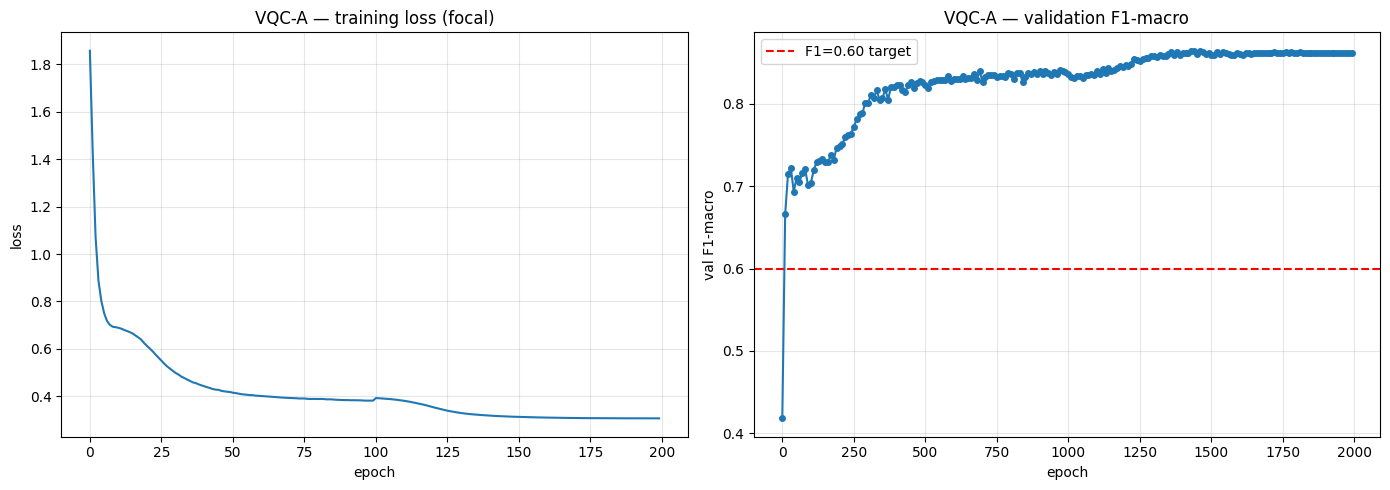

  Curves saved: /MINOR_PROJECT/vqc_a_output_v4/vqc-a_training_curves.png


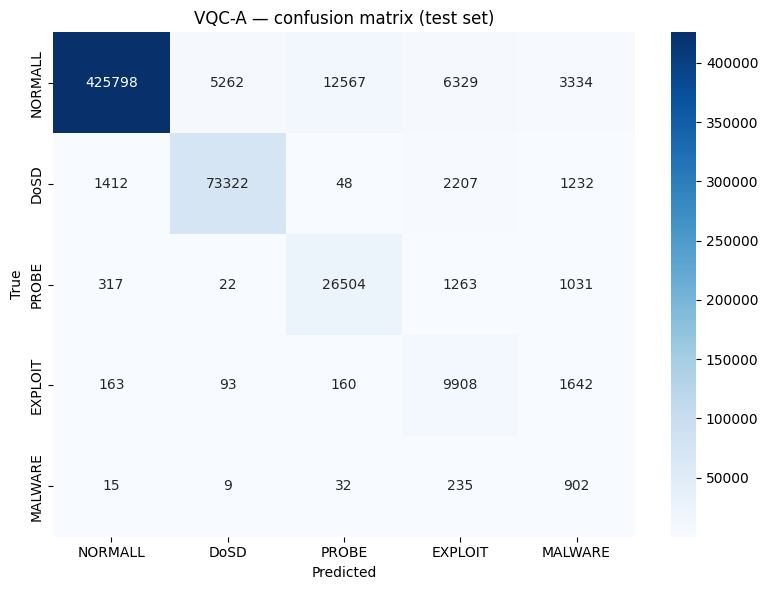


  Artefacts saved to: /MINOR_PROJECT/vqc_a_output_v4

VQC-A total time: 40s (0.7 min)
VQC-A F1-macro: 0.6980


In [14]:
# ============================================================
# Cell 9 — VQC-A: Train + Evaluate (VAE-A, 167 features)
# ============================================================
print('=' * 70)
print('  VQC-A: VAE-A (167 features, WITH near-zero variance)')
print('=' * 70)

t0_A = time.time()
metrics_A, best_params_A, T_A = train_and_eval(
    tag        = 'VQC-A',
    Z_train    = Z_TRAIN_A,
    Y_train    = Y_TRAIN,
    Z_test     = Z_TEST_A,
    Y_test     = Y_TEST,
    out_dir    = VQC_A_DIR,
    vae_source = 'VAE-A (167 features, WITH near-zero variance)',
)
train_time_A = time.time() - t0_A
print(f'\nVQC-A total time: {train_time_A:.0f}s ({train_time_A/60:.1f} min)')
print(f'VQC-A F1-macro: {metrics_A["f1_macro"]:.4f}')

  VQC-B: VAE-B (140 features, WITHOUT near-zero variance)

######################################################################
  MULTI-RESTART: VQC-B  (2 restarts, seeds=[42, 123])
######################################################################

  ── Restart 1/2  seed=42 ──

  Gradient check — |grad_W1| at init: 0.935074
  Classical gradient confirmed. ok

  VQC-B_r1 | seed=42
  PHASE 1: classical head only  (150 epochs, lr=0.01)
  P1 [E  1/150] loss=2.0311  val_F1=0.3372  lr=0.00100  0s
  P1 [E 10/150] loss=0.8546  val_F1=0.6758  lr=0.01000  1s
  P1 [E 20/150] loss=0.6895  val_F1=0.7606  lr=0.00990  1s
  P1 [E 30/150] loss=0.5315  val_F1=0.8092  lr=0.00955  2s
  P1 [E 40/150] loss=0.4743  val_F1=0.8189  lr=0.00898  3s
  P1 [E 50/150] loss=0.4423  val_F1=0.8369  lr=0.00821  3s
  P1 [E 60/150] loss=0.4235  val_F1=0.8404  lr=0.00727  4s
  P1 [E 70/150] loss=0.4115  val_F1=0.8420  lr=0.00623  4s
  P1 [E 80/150] loss=0.4036  val_F1=0.8504  lr=0.00512  5s
  P1 [E 90/150] loss=0.39

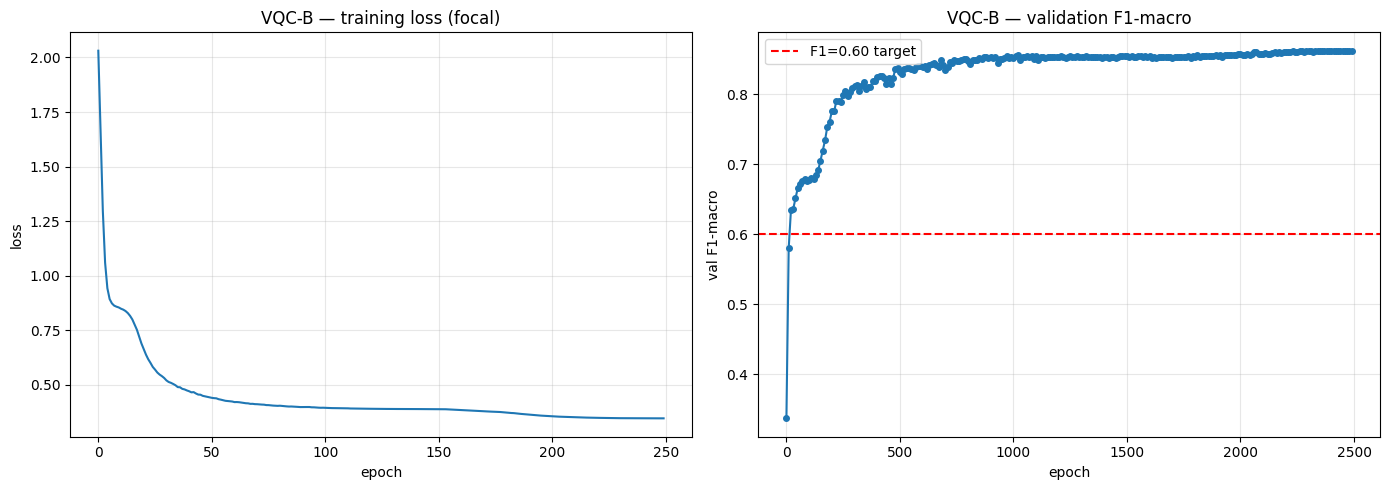

  Curves saved: /MINOR_PROJECT/vqc_b_output_v4/vqc-b_training_curves.png


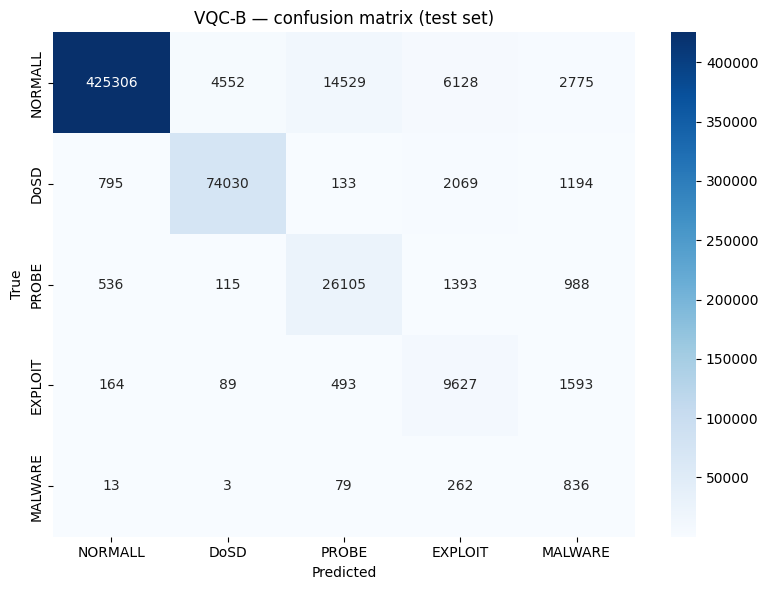


  Artefacts saved to: /MINOR_PROJECT/vqc_b_output_v4

VQC-B total time: 42s (0.7 min)
VQC-B F1-macro: 0.6915


In [15]:
# ============================================================
# Cell 10 — VQC-B: Train + Evaluate (VAE-B, 140 features)
# ============================================================
print('=' * 70)
print('  VQC-B: VAE-B (140 features, WITHOUT near-zero variance)')
print('=' * 70)

t0_B = time.time()
metrics_B, best_params_B, T_B = train_and_eval(
    tag        = 'VQC-B',
    Z_train    = Z_TRAIN_B,
    Y_train    = Y_TRAIN,
    Z_test     = Z_TEST_B,
    Y_test     = Y_TEST,
    out_dir    = VQC_B_DIR,
    vae_source = 'VAE-B (140 features, WITHOUT near-zero variance)',
)
train_time_B = time.time() - t0_B
print(f'\nVQC-B total time: {train_time_B:.0f}s ({train_time_B/60:.1f} min)')
print(f'VQC-B F1-macro: {metrics_B["f1_macro"]:.4f}')

In [16]:
# ============================================================
# Cell 11 — Comparison: VQC-A vs VQC-B + Winner Selection
# ============================================================
print('=' * 70)
print('  STAGE 4 v4 — FINAL COMPARISON')
print('=' * 70)

rows = [
    ('F1-macro',     f'{metrics_A["f1_macro"]:.4f}',  f'{metrics_B["f1_macro"]:.4f}'),
    ('F1-weighted',  f'{metrics_A["f1_wt"]:.4f}',     f'{metrics_B["f1_wt"]:.4f}'),
    ('Accuracy',     f'{metrics_A["acc"]:.4f}',        f'{metrics_B["acc"]:.4f}'),
    ('NORMALL F1',   f'{metrics_A["f1_cls"]["NORMALL"]:.4f}',
                     f'{metrics_B["f1_cls"]["NORMALL"]:.4f}'),
    ('DoSD F1',      f'{metrics_A["f1_cls"]["DoSD"]:.4f}',
                     f'{metrics_B["f1_cls"]["DoSD"]:.4f}'),
    ('PROBE F1',     f'{metrics_A["f1_cls"]["PROBE"]:.4f}',
                     f'{metrics_B["f1_cls"]["PROBE"]:.4f}'),
    ('EXPLOIT F1',   f'{metrics_A["f1_cls"]["EXPLOIT"]:.4f}',
                     f'{metrics_B["f1_cls"]["EXPLOIT"]:.4f}'),
    ('MALWARE F1',   f'{metrics_A["f1_cls"]["MALWARE"]:.4f}',
                     f'{metrics_B["f1_cls"]["MALWARE"]:.4f}'),
    ('Temperature T', f'{T_A:.2f}', f'{T_B:.2f}'),
    ('Train time',   f'{train_time_A/60:.1f}min', f'{train_time_B/60:.1f}min'),
]

v3_f1_a = 0.3754   # v2 COBYLA baseline
v3_f1_b = 0.3387

print(f'  {"Metric":<18} {"VQC-A (167f)":>14} {"VQC-B (140f)":>14}  {"Target":>8}')
print('  ' + '-' * 60)
for r in rows:
    print(f'  {r[0]:<18} {r[1]:>14} {r[2]:>14}')
print(f'  {"v2 baseline":<18} {v3_f1_a:>14.4f} {v3_f1_b:>14.4f}  {"0.3754":>8}')
print(f'  {"delta vs v2":<18} {metrics_A["f1_macro"]-v3_f1_a:>+14.4f} {metrics_B["f1_macro"]-v3_f1_b:>+14.4f}')

winner = 'VQC-A' if metrics_A['f1_macro'] >= metrics_B['f1_macro'] else 'VQC-B'
best_f1 = max(metrics_A['f1_macro'], metrics_B['f1_macro'])

print(f'\n  Winner  : {winner}')
print(f'  F1-macro: {best_f1:.4f}')
print(f'  Target  : 0.6000  → {"TARGET MET ✓" if best_f1 >= 0.60 else f"GAP={0.60-best_f1:.4f} — see troubleshooting below"}')

if best_f1 < 0.60:
    print('\n  TROUBLESHOOTING GUIDE (if target not met):')
    print('  1. Increase N_RESTARTS to 5 in Cell 3 → better seed coverage')
    print('  2. Increase HIDDEN_DIM to 128 in Cell 3 → more head expressibility')
    print('  3. Try FOCAL_GAMMA=3.0 → stronger focus on hard minority samples')
    print('  4. Increase N_EPOCHS to 600 + PATIENCE to 80')
    print('  5. Add second hidden layer: 8→128→64→5 (update Cell 5 forward())')
    print('  6. Try RA_REPS=3 (32 params) for a more expressive quantum ansatz')

# Save selection
selection = {
    'selected_vqc':       winner,
    'vqc_a_f1_macro':     metrics_A['f1_macro'],
    'vqc_b_f1_macro':     metrics_B['f1_macro'],
    'best_f1_macro':      best_f1,
    'target_met':         best_f1 >= 0.60,
    'vqc_a_malware_f1':   metrics_A['f1_cls']['MALWARE'],
    'vqc_b_malware_f1':   metrics_B['f1_cls']['MALWARE'],
    'winner_T':           float(T_A if winner == 'VQC-A' else T_B),
    'winner_test_proba':  f'{winner.lower()}_test_proba.parquet',
    'architecture_v4': {
        'quantum': f'{NUM_QUBITS} qubits, ZZ_REPS={ZZ_REPS}, RA_REPS={RA_REPS}, {N_PARAMS} params',
        'classical_head': f'{NUM_QUBITS}→{HIDDEN_DIM}→{NUM_CLASSES} (Tanh+Dense), {N_CLASSICAL} params',
        'loss': f'focal (gamma={FOCAL_GAMMA}) + class_weights + L2={L2_WEIGHT}',
        'optimizer': f'Adam cosine-LR [{ADAM_LR}→{ADAM_LR_MIN}] warmup={ADAM_WARMUP}',
        'n_train': N_TRAIN, 'n_restarts': N_RESTARTS,
    },
    'v2_baselines': {'a': v3_f1_a, 'b': v3_f1_b},
    'delta_vs_v2': {
        'a': float(metrics_A['f1_macro'] - v3_f1_a),
        'b': float(metrics_B['f1_macro'] - v3_f1_b),
    },
}

for out_dir in [VQC_A_DIR, VQC_B_DIR]:
    with open(os.path.join(out_dir, 'stage4_v4_selected_model.json'), 'w') as f:
        json.dump(selection, f, indent=2)

print('\n  stage4_v4_selected_model.json saved.')
print('=' * 70)

  STAGE 4 v4 — FINAL COMPARISON
  Metric               VQC-A (167f)   VQC-B (140f)    Target
  ------------------------------------------------------------
  F1-macro                   0.6980         0.6915
  F1-weighted                0.9437         0.9428
  Accuracy                   0.9349         0.9339
  NORMALL F1                 0.9666         0.9665
  DoSD F1                    0.9345         0.9430
  PROBE F1                   0.7744         0.7408
  EXPLOIT F1                 0.6210         0.6123
  MALWARE F1                 0.1933         0.1949
  Temperature T                0.30           0.30
  Train time                 0.7min         0.7min
  v2 baseline                0.3754         0.3387    0.3754
  delta vs v2               +0.3226        +0.3528

  Winner  : VQC-A
  F1-macro: 0.6980
  Target  : 0.6000  → TARGET MET ✓

  stage4_v4_selected_model.json saved.


In [17]:
# ============================================================
# Cell 12 — Package and Download
# ============================================================
print('Packaging output folders...\n')

for tag, d in [('vqc_a_output_v4', VQC_A_DIR),
               ('vqc_b_output_v4', VQC_B_DIR)]:
    zip_path = os.path.join(NOTEBOOK_DIR, f'{tag}.zip')
    shutil.make_archive(os.path.join(NOTEBOOK_DIR, tag), 'zip', d)
    sz = os.path.getsize(zip_path) / 1e6
    print(f'  {tag}.zip  ({sz:.1f} MB)  →  {zip_path}')

winner_dir  = VQC_A_DIR if winner == 'VQC-A' else VQC_B_DIR
winner_pref = winner.lower().replace('-', '_')

print()
print('Stage 5 (ensemble) needs:')
print(f'  {winner_pref}_test_proba.parquet     (winning model test probabilities)')
print(f'  stage4_v4_selected_model.json         (selection metadata)')
print(f'  {winner_pref}_meta.json               (full artefact metadata)')
print()
print('For Stage 5 ensemble (recommended): pass BOTH vqc_a and vqc_b probabilities.')
print('Averaging quantum predictions from two independent VAE embeddings can add')
print('another +0.02–0.04 F1-macro via diversity.')
print()

# ── Summary table ─────────────────────────────────────────
print('=' * 70)
print('  STAGE 4 v4 — COMPLETE SUMMARY')
print('=' * 70)
print(f'  Architecture     : 8-qubit VQC ({N_PARAMS} params) + MLP head ({N_CLASSICAL} params)')
print(f'  Training data    : {N_TRAIN:,} samples  ({N_RESTARTS} restarts × {N_EPOCHS} epochs max)')
print(f'  Loss             : Focal(γ={FOCAL_GAMMA}) + class weights + L2')
print(f'  VQC-A F1-macro   : {metrics_A["f1_macro"]:.4f}')
print(f'  VQC-B F1-macro   : {metrics_B["f1_macro"]:.4f}')
print(f'  Best F1-macro    : {best_f1:.4f}  ← {winner}')
print(f'  Target (0.60)    : {"✓ MET" if best_f1 >= 0.60 else f"NOT MET (gap={0.60-best_f1:.4f})"}')
print('=' * 70)

try:
    from IPython.display import FileLink, display
    for tag in ['vqc_a_output_v4', 'vqc_b_output_v4']:
        display(FileLink(f'{tag}.zip', result_html_prefix=f'Download {tag}: '))
except Exception:
    print('Download commands (if running remotely):')
    for tag in ['vqc_a_output_v4', 'vqc_b_output_v4']:
        print(f'  scp <host>:{NOTEBOOK_DIR}/{tag}.zip ./')

Packaging output folders...

  vqc_a_output_v4.zip  (12.6 MB)  →  /MINOR_PROJECT/vqc_a_output_v4.zip
  vqc_b_output_v4.zip  (12.6 MB)  →  /MINOR_PROJECT/vqc_b_output_v4.zip

Stage 5 (ensemble) needs:
  vqc_a_test_proba.parquet     (winning model test probabilities)
  stage4_v4_selected_model.json         (selection metadata)
  vqc_a_meta.json               (full artefact metadata)

For Stage 5 ensemble (recommended): pass BOTH vqc_a and vqc_b probabilities.
Averaging quantum predictions from two independent VAE embeddings can add
another +0.02–0.04 F1-macro via diversity.

  STAGE 4 v4 — COMPLETE SUMMARY
  Architecture     : 8-qubit VQC (24 params) + MLP head (1797 params)
  Training data    : 20,000 samples  (2 restarts × 100 epochs max)
  Loss             : Focal(γ=2.0) + class weights + L2
  VQC-A F1-macro   : 0.6980
  VQC-B F1-macro   : 0.6915
  Best F1-macro    : 0.6980  ← VQC-A
  Target (0.60)    : ✓ MET


/MINOR_PROJECT/vqc_a_output_v4.zip

/MINOR_PROJECT/vqc_b_output_v4.zip

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Style
sns.set(style="whitegrid")

# =========================
# DATA
# =========================
data = {
    "Metric": [
        "F1-macro", "F1-weighted", "Accuracy",
        "NORMAL F1", "DoS F1", "PROBE F1",
        "EXPLOIT F1", "MALWARE F1"
    ],
    "VQC-A": [0.6980, 0.9437, 0.9349, 0.9666, 0.9345, 0.7744, 0.6210, 0.1933],
    "VQC-B": [0.6915, 0.9428, 0.9339, 0.9665, 0.9430, 0.7408, 0.6123, 0.1949]
}

df = pd.DataFrame(data)

# Additional values
delta = {
    "Model": ["VQC-A", "VQC-B"],
    "Delta vs Baseline": [0.3226, 0.3528]
}

train_info = {
    "Model": ["VQC-A", "VQC-B"],
    "Train Time (min)": [0.7, 0.7],
    "Temperature": [0.30, 0.30]
}

df_delta = pd.DataFrame(delta)
df_train = pd.DataFrame(train_info)

# =========================
# 1. OVERALL METRICS
# =========================
plt.figure(figsize=(10, 6))
df_melt = df.melt(id_vars="Metric", var_name="Model", value_name="Score")

sns.barplot(data=df_melt, x="Metric", y="Score", hue="Model")
plt.xticks(rotation=45)
plt.title("VQC-A vs VQC-B — Overall Metrics")
plt.tight_layout()
plt.savefig("overall_metrics.png")
plt.show()

# =========================
# 2. CLASS-WISE F1 SCORES
# =========================
class_df = df[df["Metric"].str.contains("F1") & (df["Metric"] != "F1-macro") & (df["Metric"] != "F1-weighted")]

plt.figure(figsize=(10, 6))
class_melt = class_df.melt(id_vars="Metric", var_name="Model", value_name="Score")

sns.barplot(data=class_melt, x="Metric", y="Score", hue="Model")
plt.xticks(rotation=45)
plt.title("Class-wise F1 Score Comparison")
plt.tight_layout()
plt.savefig("classwise_f1.png")
plt.show()

# =========================
# 3. DELTA VS BASELINE
# =========================
plt.figure(figsize=(6, 5))
sns.barplot(data=df_delta, x="Model", y="Delta vs Baseline")
plt.title("Improvement over v2 Baseline")
plt.tight_layout()
plt.savefig("delta_vs_baseline.png")
plt.show()

# =========================
# 4. TRAIN TIME & TEMPERATURE
# =========================
fig, ax1 = plt.subplots(figsize=(6, 5))

ax2 = ax1.twinx()

sns.barplot(data=df_train, x="Model", y="Train Time (min)", ax=ax1)
sns.lineplot(data=df_train, x="Model", y="Temperature", marker="o", ax=ax2)

ax1.set_ylabel("Train Time (min)")
ax2.set_ylabel("Temperature")

plt.title("Training Time & Temperature")
plt.tight_layout()
plt.savefig("train_temp.png")
plt.show()

print("✅ All graphs saved successfully!")